# VarChAMP variants → AnnData

Coding variants profiled across fourteen batches ([`cpg0020`](https://broadinstitute.github.io/cellpainting-gallery/)). Intersecting features across all batches leaves only thirteen, so a single batch is used. Twenty wells appear twice under the same plate and well identifier, so the default index is kept rather than a plate/well key.

One observation is a well, one variable is a CellProfiler feature.
Well-level profiles only, no images:

```bash
aws s3 cp --no-sign-request --recursive --exclude "*" --include "*_normalized_feature_select_batch.csv.gz" \
  s3://cellpainting-gallery/cpg0020-varchamp/broad/workspace/profiles/ .
```

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import scanpy as sc

import cell_painting_io as cpio

PROFILES = Path("~/data/cpg0020-varchamp/profiles").expanduser()

## Scoping to one batch

Feature selection ran per batch, so batches carry different feature sets and intersecting across them throws most features away.
This takes the batch with the most plates.

In [2]:
batches = sorted({p.parents[1].name for p in PROFILES.glob("*/*/*.csv.gz")})
BATCH = max(batches, key=lambda b: len(list((PROFILES / b).glob("*/*"))))
print(f"{len(batches)} batches, using {BATCH}")
files = sorted((PROFILES / BATCH).glob("*/*"))

14 batches, using 2024_01_23_Batch_7


In [3]:
adata = cpio.read_profiles(files, path_columns={"batch": 2, "plate_dir": 1}, on_column_mismatch="intersect")
adata

/home/lheumos/code/cell-painting-io/cell_painting_io.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame[name] = path.parents[depth - 1].name
/home/lheumos/code/cell-painting-io/cell_painting_io.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame[name] = path.parents[depth - 1].name
/home/lheumos/code/cell-painting-io/cell_painting_io.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns 

AnnData object with n_obs × n_vars = 7177 × 863
    obs: 'plate_map_name', 'control_type', 'gene_allele', 'DNA_entry_plate', 'DNA_entry_well', 'DNA_entry_num', 'DNA_dest_plate', 'DNA_dest_well', 'DNA_dest_numb', 'allele_set', 'imaging_plate', 'imaging_well', 'batch1', 'batch2', 'orf_ID', 'hgnc_symbol', 'clone_ID', 'hgmd_ID', 'mut_ID', 'clinvar_allele_ID', 'clinvar_clinical_significance', 'node_type', 'nt_change', 'aa_change', 'vector', 'notes', 'Plate', 'Well', 'Site_Count', 'Object_Count', 'batch', 'plate_dir'
    layers: None (.X)

In [4]:
cpio.annotate_features(adata.var)
adata = cpio.drop_incomplete_features(adata)
adata = cpio.drop_extreme_features(adata)
adata = cpio.drop_constant_features(adata)


def present(columns):
    return [c for c in columns if c in adata.obs.columns and adata.obs[c].nunique() > 1]


cpio.categorize(adata, present(["plate_dir", "Plate", "plate_map_name"]))
adata.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
Cells_AreaShape_BoundingBoxMaximum_X,cells,areashape,NaN,NaN,0
Cells_AreaShape_Compactness,cells,areashape,NaN,NaN,0
Cells_AreaShape_Eccentricity,cells,areashape,NaN,NaN,0
Cells_AreaShape_Extent,cells,areashape,NaN,NaN,0
Cells_AreaShape_FormFactor,cells,areashape,NaN,NaN,0
...,...,...,...,...,...
Nuclei_Texture_SumVariance_DNA_20_00_256,nuclei,texture,dna,NaN,1
Nuclei_Texture_SumVariance_DNA_20_01_256,nuclei,texture,dna,NaN,1
Nuclei_Texture_SumVariance_GFP_10_01_256,nuclei,texture,NaN,NaN,0


## Sanity checks

In [5]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features")
print(f"non-finite: {int((~np.isfinite(adata.X)).sum())} | max|x|: {np.abs(adata.X).max():.1f}")
for column in present(["plate_dir"]):
    print(f"\n{column}:")
    print(adata.obs[column].value_counts(dropna=False).head(6).to_string())

7,177 wells x 853 features
non-finite: 0 | max|x|: 33365.0

plate_dir:
plate_dir
2024_01_17_B7A1R1_P1T2    384
2024_01_17_B7A1R1_P1T3    384
2024_01_17_B7A1R1_P1T4    384
2024_01_17_B7A1R1_P2T4    384
2024_01_19_B7A1R1_P3T2    384
2024_01_19_B7A1R1_P3T3    384


In [6]:
adata.write_h5ad(PROFILES.parent / "varchamp.h5ad")

## UMAP

The profiles are already normalized, so they enter PCA unscaled.

In [7]:
sc.pp.pca(adata, n_comps=min(50, adata.n_vars - 1))
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


How often do neighbouring wells share a label, against the rate expected if labels were shuffled?
Above 1 means the covariate explains part of the embedding.

In [8]:
cpio.neighbour_enrichment(adata, present(["plate_dir", "plate_map_name"]))

,observed,baseline,ratio
covariate,,,
plate_dir,0.139,0.050,2.754
plate_map_name,0.339,0.201,1.683


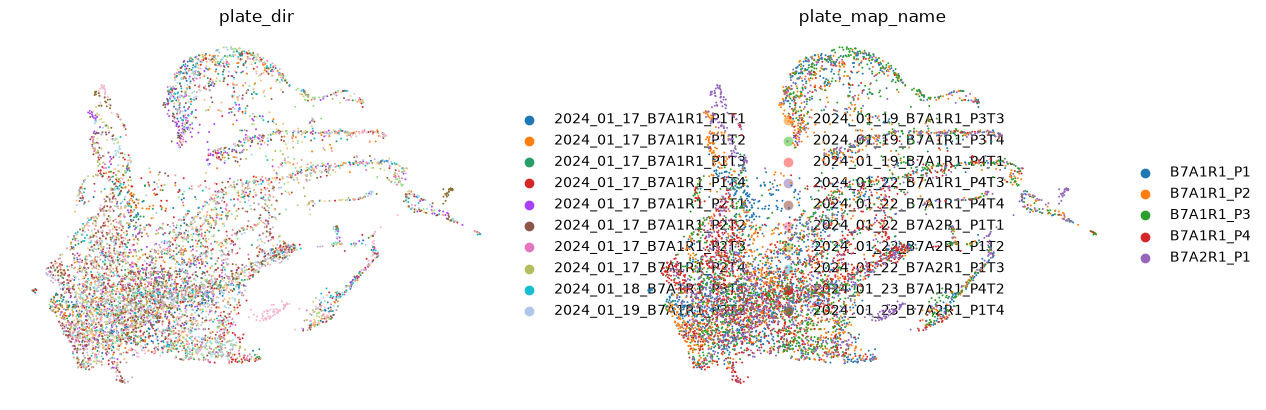

In [9]:
sc.pl.umap(adata, color=present(["plate_dir", "plate_map_name", "Count_Cells"])[:3], ncols=3, frameon=False, size=8)